# Dataset Verification and Sanity Check

## Project Context

Exploring **cross-subject motor imagery EEG classification**. The goal is to understand whether a simple baseline model (CSP + LDA) can generalize to unseen subjects in a brain-computer interface (BCI) context.

## Dataset used
**BNCI2014_001**  
A well-established motor imagery benchmark with 9 subjects, 2 sessions each, and 4 motor imagery classes. It's manageable in size and widely used in BCI research.

**Left/Right Hand Imagery Classification**  
I'm simplifying the task to binary classification (left vs right hand motor imagery) using the `LeftRightImagery` paradigm from MOABB.

## Purpose of this notebook:
- Verify the environment and imports
- Confirm dataset availability
- Inspect basic metadata
- Perform a small sanity check on one subject

# 1. Setup

## 1.1. Imports 

In [1]:
import numpy as np
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery

import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
import mne

/Users/vadim/Documents/School/Spring 2026/CSCE A662 Advanced Data Mining/Assignments/Assignment 2/bci-inefficiency-analysis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Data

## 2.1. Dataset Setup

In [2]:
dataset = BNCI2014_001()
paradigm = LeftRightImagery()

## 2.2. Dataset Metadata Inspection

In [3]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Number of subjects: {len(dataset.subject_list)}")
print(f"Subject IDs: {dataset.subject_list}")
print(f"Number of sessions: {dataset.n_sessions}")
print(f"Event IDs (all classes): {dataset.event_id}")

DATASET INFORMATION
Number of subjects: 9
Subject IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of sessions: 2
Event IDs (all classes): {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'tongue': 4}


In [4]:
print("\n" + "=" * 60)
print("PARADIGM INFORMATION")
print("=" * 60)

# Paradigm details
print(f"Frequency filters: {paradigm.filters}")
print(f"Paradigm events (left/right only): {paradigm.events}")


PARADIGM INFORMATION
Frequency filters: [[8, 32]]
Paradigm events (left/right only): ['left_hand', 'right_hand']


# 3. Subject

## 3.1. Lightweight Subject-Level Sanity Check

Check:
- Data can be fetched successfully
- The shape and structure make sense
- Left vs right classes are balanced

In [5]:
SUBJECTS = [1]

print(f"Loading data for subjects: {SUBJECTS}\n")
X, labels, metadata = paradigm.get_data(dataset=dataset, subjects=SUBJECTS) # type: ignore

Loading data for subjects: [1]



In [6]:
print("=" * 60)
print("DATA SHAPES AND STRUCTURE")
print("=" * 60)
print(f"X shape: {X.shape}")
print(f"  - Number of trials: {X.shape[0]}")
print(f"  - Number of channels: {X.shape[1]}")
print(f"  - Number of time samples: {X.shape[2]}")

print(f"\nlabels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
unique, counts = np.unique(labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class '{label}': {count} trials")

DATA SHAPES AND STRUCTURE
X shape: (288, 22, 1001)
  - Number of trials: 288
  - Number of channels: 22
  - Number of time samples: 1001

labels shape: (288,)
Unique labels: ['left_hand' 'right_hand']

CLASS DISTRIBUTION
Class 'left_hand': 144 trials
Class 'right_hand': 144 trials


## 3.2. Visualization of EEG Data

In [7]:
X[0].shape

(22, 1001)

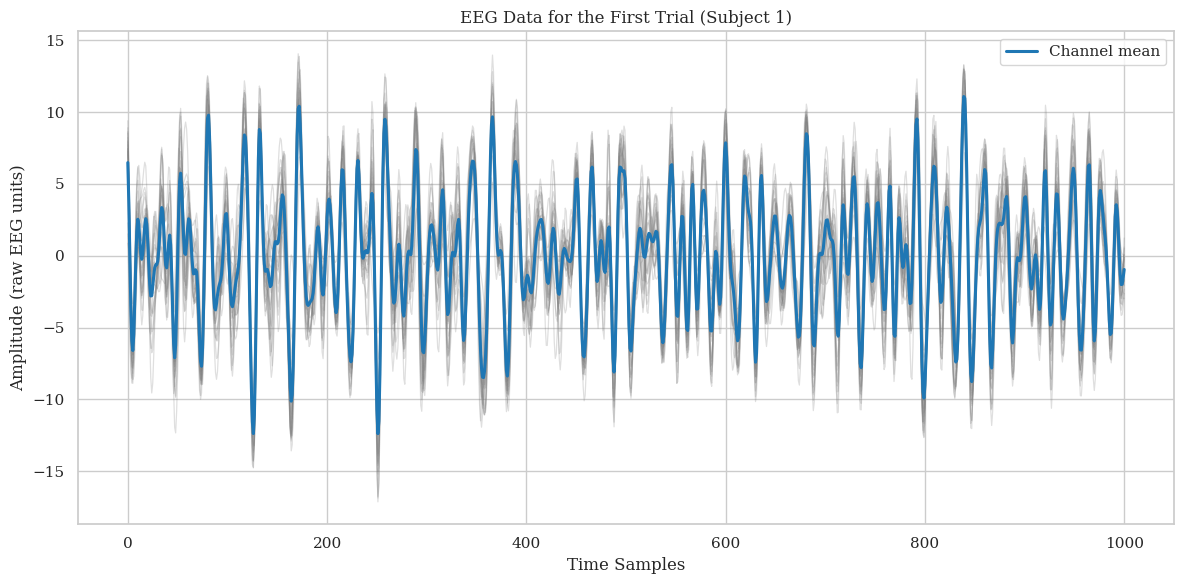

In [8]:
trial = X[0]  # shape: (n_channels, n_times)
mean_trace = trial.mean(axis=0)

plt.figure(figsize=(12, 6))

# Plot every channel on the same axis (no vertical offset)
for ch in trial:
    plt.plot(ch, color="gray", alpha=0.25, linewidth=0.9)

# Emphasize the average activity across channels for readability
plt.plot(mean_trace, color="tab:blue", linewidth=2.2, label="Channel mean")

plt.title("EEG Data for the First Trial (Subject 1)")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude (raw EEG units)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

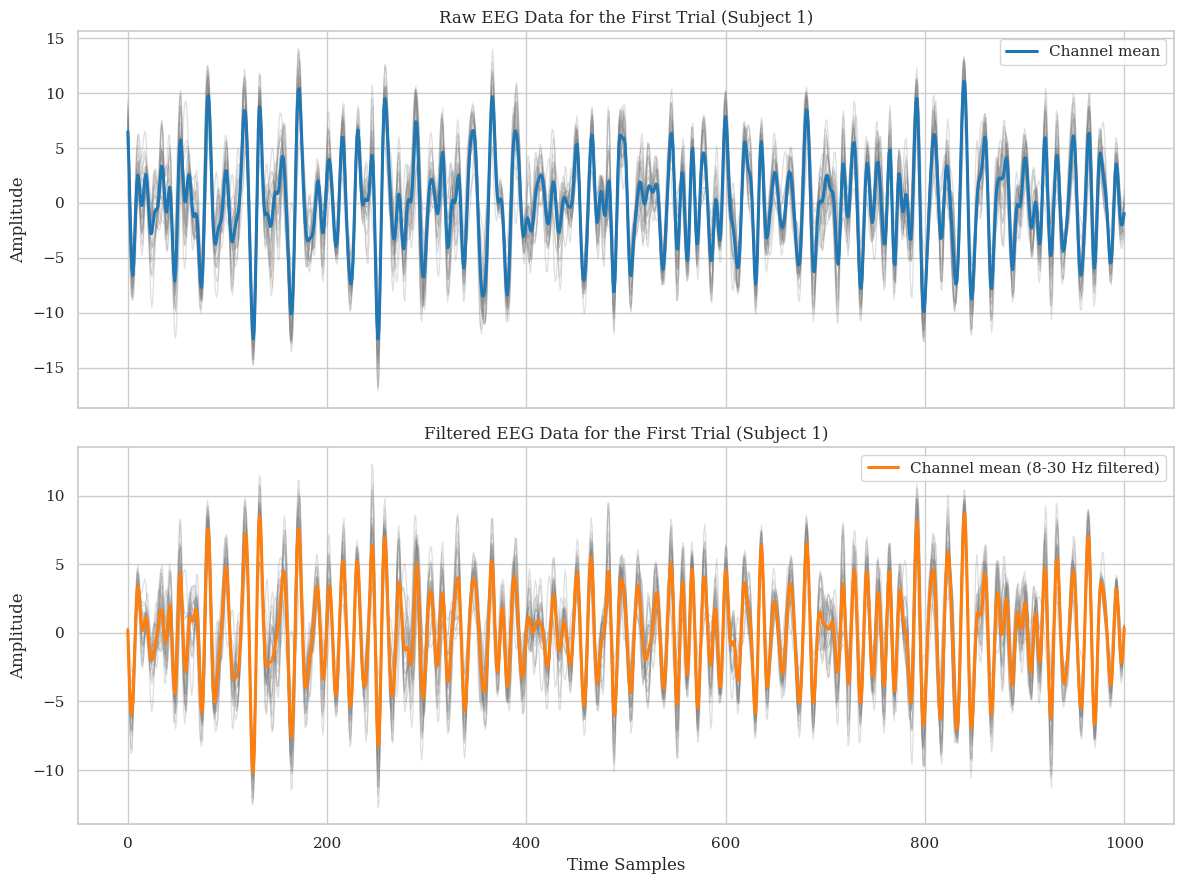

In [ ]:
sfreq = 250.0
trial = X[0]

low_hz = 8
high_hz = 30.0
sos = butter(
    N=4,
    Wn=[low_hz, high_hz],
    btype="bandpass",
    fs=sfreq,
    output="sos"
)

trial_filtered = sosfiltfilt(sos, trial, axis=1)

mean_trace_raw = trial.mean(axis=0)
mean_trace_filtered = trial_filtered.mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Raw
for ch in trial:
    axes[0].plot(ch, color="gray", alpha=0.25, linewidth=0.9)
axes[0].plot(mean_trace_raw, color="tab:blue", linewidth=2.2, label="Channel mean")
axes[0].set_title("Raw EEG Data for the First Trial (Subject 1)")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right")

# Filtered
for ch in trial_filtered:
    axes[1].plot(ch, color="gray", alpha=0.25, linewidth=0.9)
axes[1].plot(
    mean_trace_filtered,
    color="tab:orange",
    linewidth=2.2,
    label="Channel mean (8-30 Hz filtered)"
)
axes[1].set_title("Filtered EEG Data for the First Trial (Subject 1)")
axes[1].set_xlabel("Time Samples")
axes[1].set_ylabel("Amplitude")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3.3. Electrode Positions and Arrangement

In [10]:
EEG_CHANNELS_22 = [
    "Fz",
    "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P1", "Pz", "P2",
    "POz",
]

trial = X[0]
info = mne.create_info(EEG_CHANNELS_22, sfreq=250.0, ch_types="eeg")
info.set_montage(mne.channels.make_standard_montage("standard_1020"))
evoked = mne.EvokedArray(trial, info, tmin=0.0)

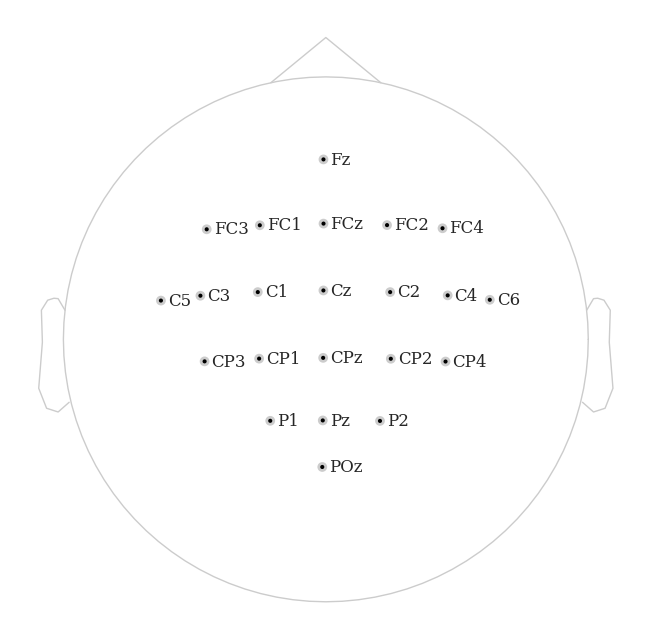

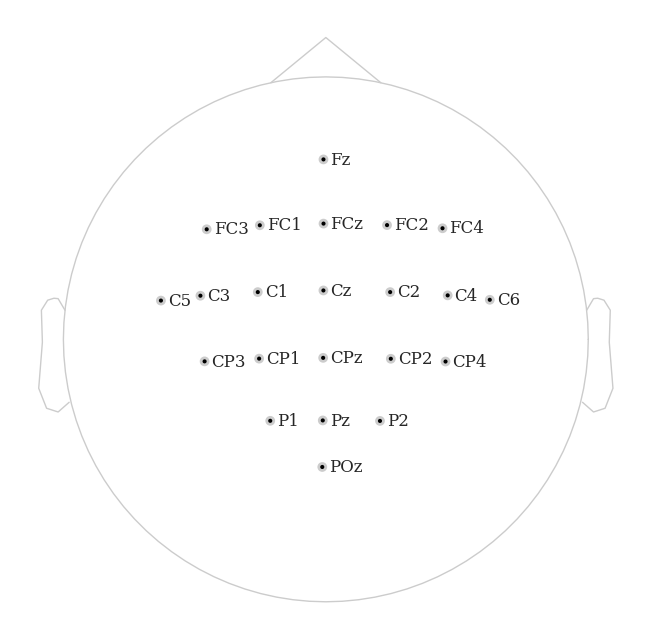

In [11]:
evoked.plot_sensors(show_names=True)

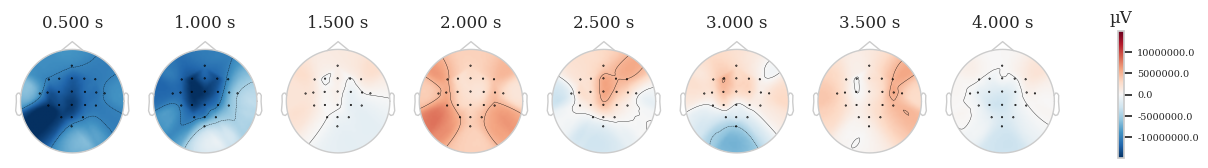

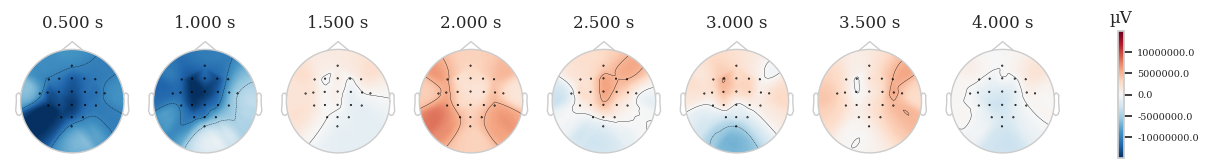

In [16]:
evoked.plot_topomap(times=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0], ch_type="eeg")

## 3.4. Separated EEG Signals by Channel

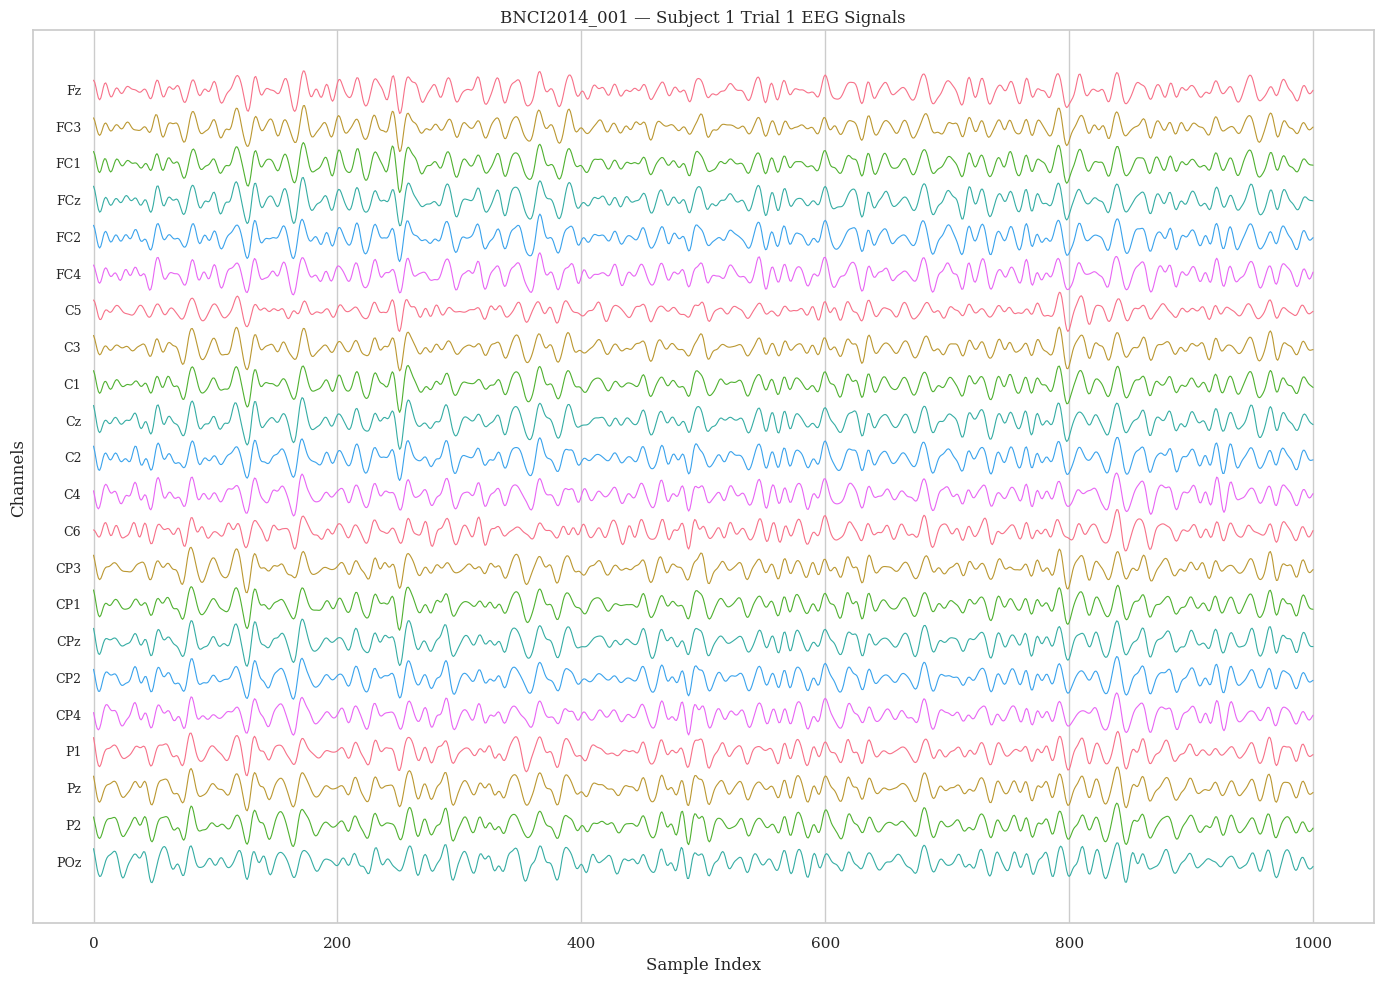

In [13]:
EEG_CHANNELS_22 = [
    "Fz",
    "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P1", "Pz", "P2",
    "POz",
]

trial = X[0]  # Subject 1, Trial 1 assuming current notebook ordering
assert trial.shape[0] == 22, f"Expected 22 EEG channels, got {trial.shape[0]}"

n_channels, n_times = trial.shape
time = np.arange(n_times)

offset = 5 * np.std(trial)
offsets = np.arange(n_channels)[::-1] * offset

plt.figure(figsize=(14, 10))
for i, ch_name in enumerate(EEG_CHANNELS_22):
    plt.plot(time, trial[i] + offsets[i], linewidth=0.8)
    plt.text(time[0] - 10, offsets[i], ch_name, va="center", ha="right", fontsize=9)

plt.title("BNCI2014_001 — Subject 1 Trial 1 EEG Signals")
plt.xlabel("Sample Index")
plt.ylabel("Channels")
plt.yticks([])
plt.tight_layout()
plt.show()

# 4. Summary

**Verification checklist:**

- Dataset import successful  
- Paradigm selection successful (LeftRightImagery)  
- Sanity-check data loading successful for one subject  
- Data shapes and class distribution look reasonable  